In [1]:
from Quelccaya import quel
import numpy as np
from IPython.display import display, Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
#%matplotlib notebook
%matplotlib inline

MOOGSILENT is available in /home/ale_blgr/q2-tools/MOOG-for-q2


In [2]:
starid   = 'HIP18844.fits'    #name of the spectra
teff     = 5734
err_teff = 10
logg     = 4.365
err_logg = 0.011
feh      = 0.014
err_feh  = 0.01
vt       = 1.01
err_vt   = 0.01
vsini    = 1.62           
macro_v  = 3.15   
resol    = 115000
SNR      = 200

In [63]:
line        = 4019.1290    #line to be synthetized and listed in syn.li
wl_start    = line - 0.9   #left wavelength limit
wl_end      = line + 0.9   #right wavelength limit
ab_lm       = 0.3          #bound limits in abundance
nsteps      = 800

#shifts
y_shift_mult = 0.000     #flux shift applied to the observed spectrum
wl_shift     = 0.000    #wavelength shift applied to the observed spectrum

### Initial abundances

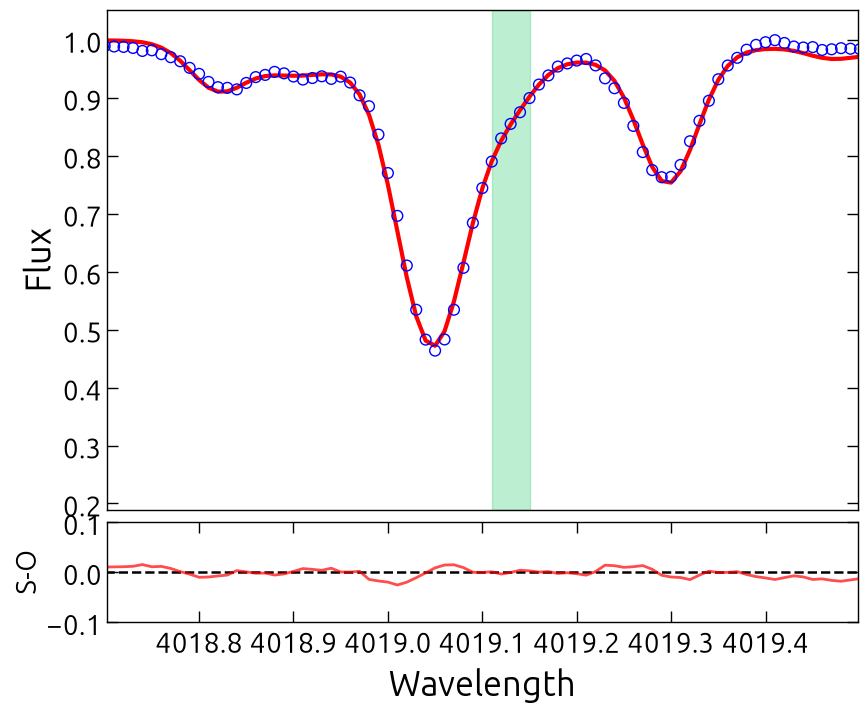

In [105]:
Th = quel.Th(starid=starid, teff=teff, logg=logg, feh=feh, vt=vt, wl_start=wl_start, wl_end=wl_end, line=line, 
         resol=resol, vsini=vsini, macro_v=macro_v, y_shift_mult=y_shift_mult, wl_shift=wl_shift)

### BAYESIAN METHOD

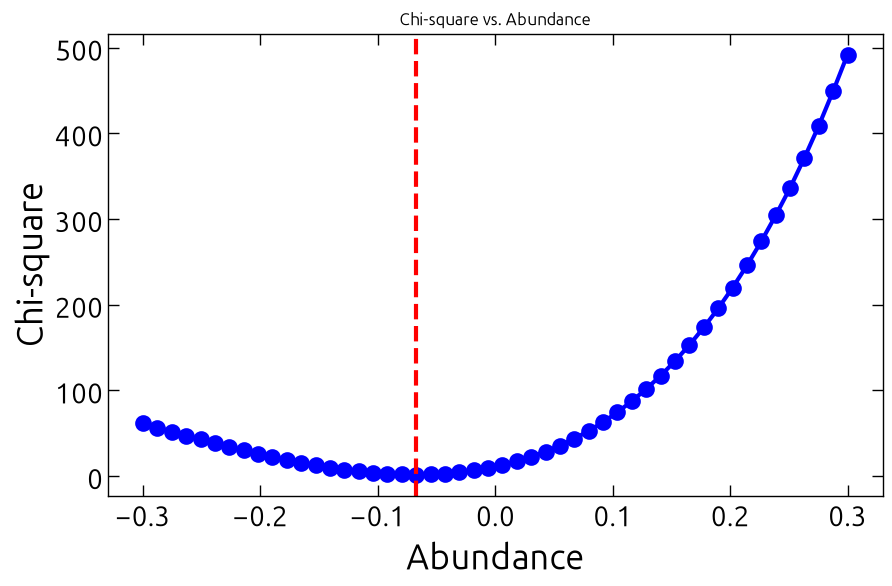

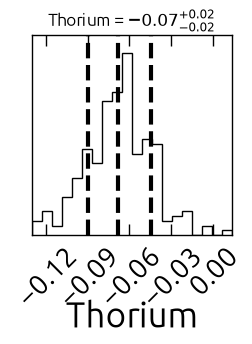

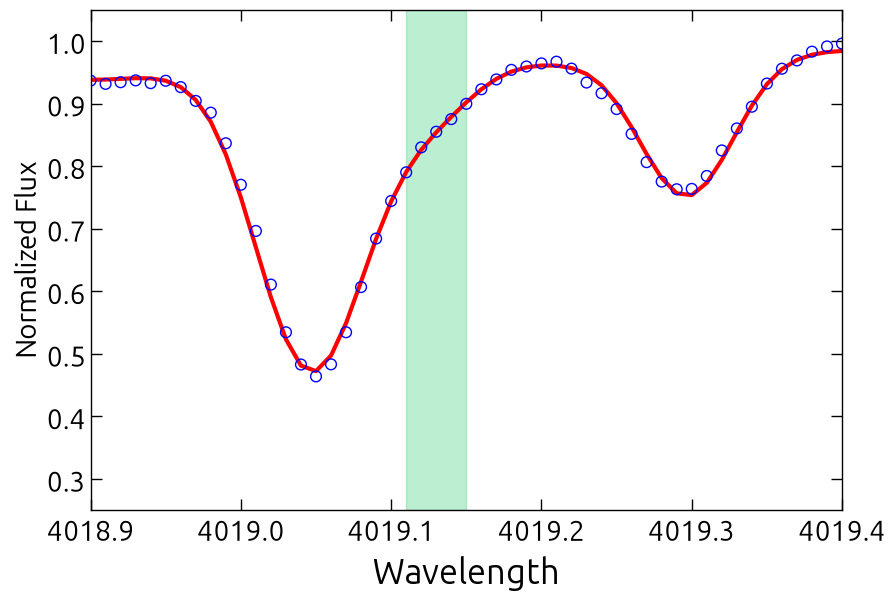

In [99]:
best_fit_abundance = quel.Th_mcmc(starid=starid, teff=teff, logg=logg, feh=feh, vt=vt, ab_lm=ab_lm, 
                                  nsteps=nsteps, wl_start=wl_start, wl_end=wl_end, line=line, resol=resol, 
                                  vsini=vsini, macro_v=macro_v, SNR=SNR, y_shift_mult=y_shift_mult, 
                                  wl_shift=wl_shift)

In [106]:
best_fit_abundance

pure_value = float(best_fit_abundance)
print(pure_value)

-0.06788179514376909


### Observational Error

mv: cannot stat 'smoothed.out': No such file or directory
cp: cannot stat 'smoothed.out': No such file or directory
mv: cannot stat 'smoothed.out': No such file or directory


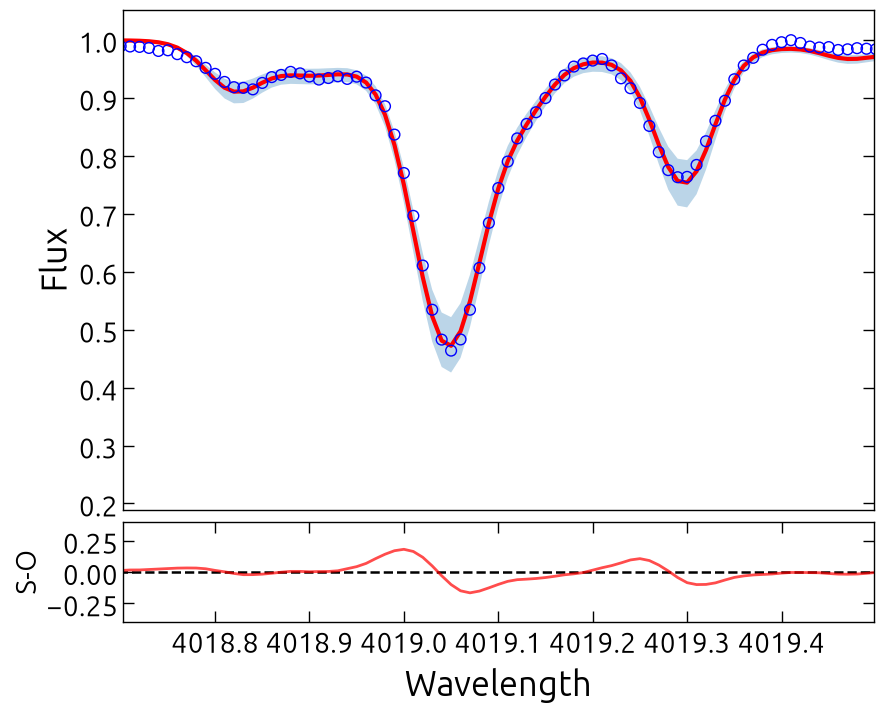

In [124]:
Th, Th_up, Th_low = quel.Th_err(starid=starid, teff=teff, logg=logg, feh=feh, vt=vt, wl_start=wl_start, 
                               wl_end=wl_end, line=line, resol=resol, vsini=vsini, macro_v=macro_v, 
                               y_shift_mult=y_shift_mult, wl_shift=wl_shift)

In [125]:
Th, Th_up, Th_low

(-0.03, -0.009999999999999998, -0.03)

### Error due to Teff

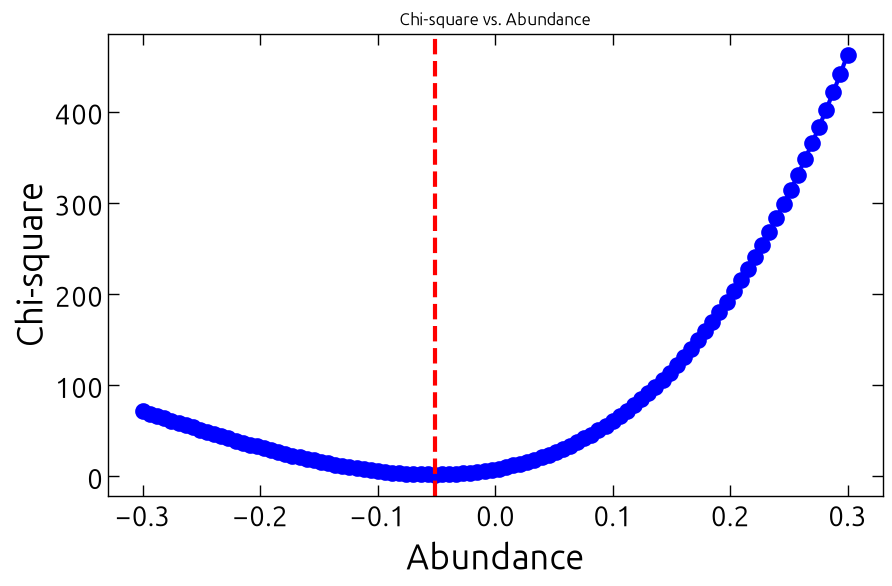

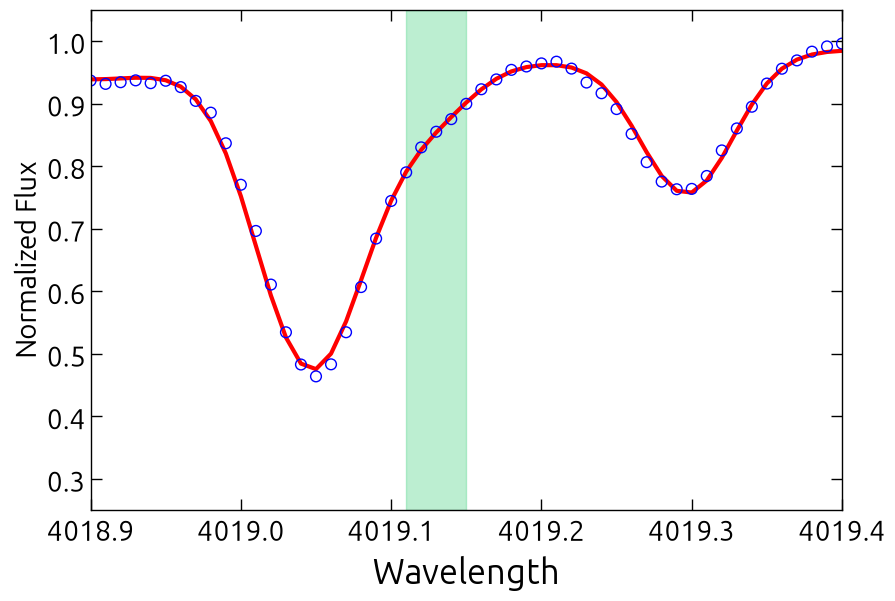

In [126]:
teffn    = teff + err_teff
Th_teffn = quel.Th_ximin(starid=starid, teff=teffn, logg=logg, feh=feh, vt=vt, ab_lm=ab_lm, 
                                  nsteps=nsteps, wl_start=wl_start, wl_end=wl_end, line=line, resol=resol, 
                                  vsini=vsini, macro_v=macro_v, SNR=SNR, y_shift_mult=y_shift_mult, 
                                  wl_shift=wl_shift)

In [128]:
Th_teff = abs(best_fit_abundance - Th_teffn)
Th_teff

pure_value = float(Th_teff)
print(pure_value)

0.016366643628617575


### Error due to logg

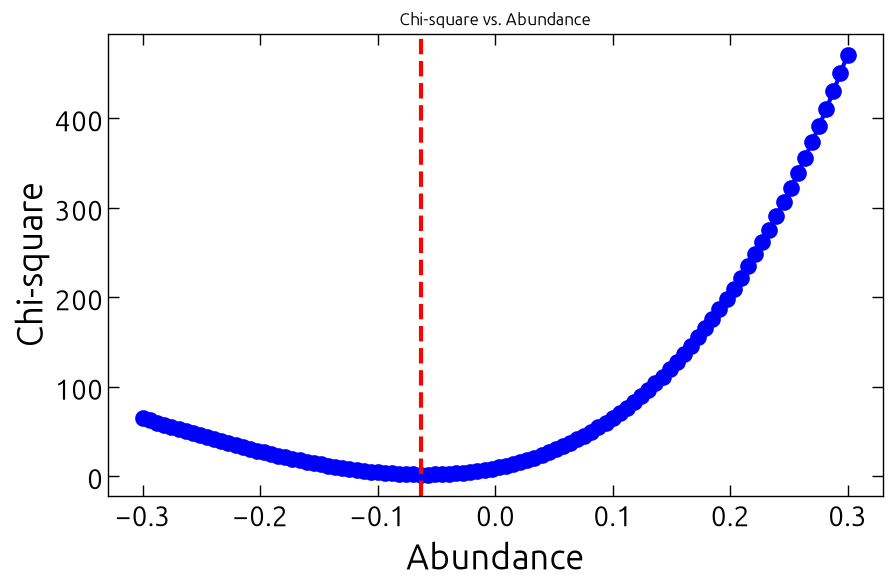

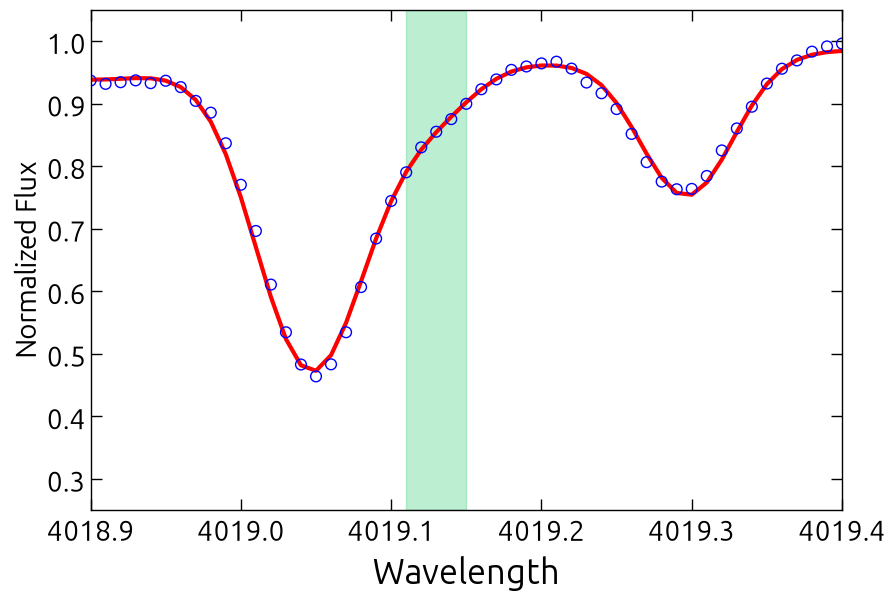

In [129]:
loggn  = logg + err_logg

Th_loggn = quel.Th_ximin(starid=starid, teff=teff, logg=loggn, feh=feh, vt=vt, ab_lm=ab_lm, 
                                  nsteps=nsteps, wl_start=wl_start, wl_end=wl_end, line=line, resol=resol, 
                                  vsini=vsini, macro_v=macro_v, SNR=SNR, y_shift_mult=y_shift_mult, 
                                  wl_shift=wl_shift)

In [130]:
Th_logg = abs(best_fit_abundance - Th_loggn)
Th_logg

pure_value = float(Th_logg)
print(pure_value)

0.004245431507405459


### Error due to feh

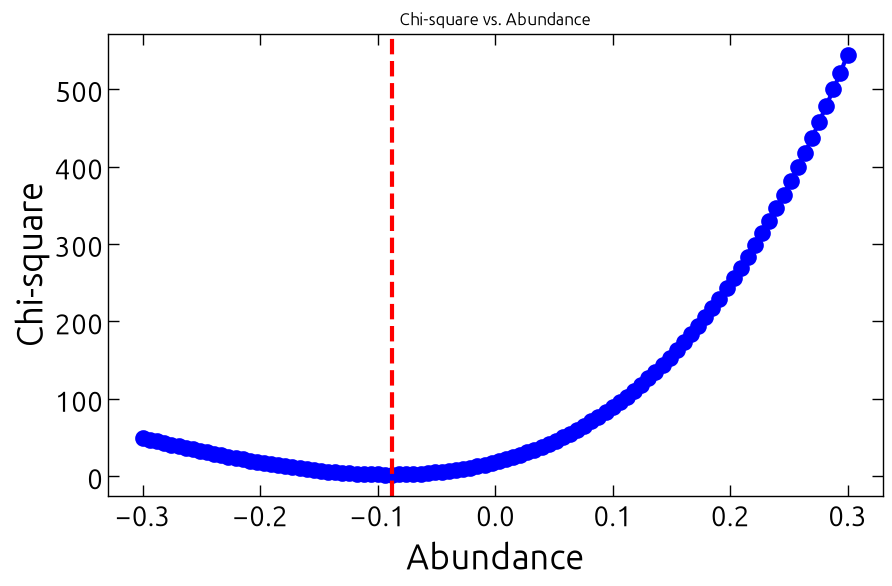

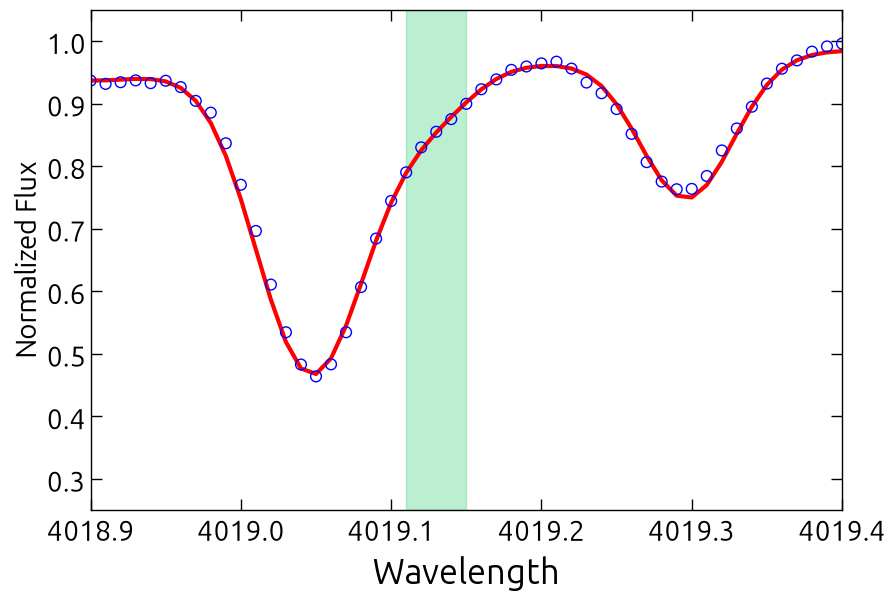

In [131]:
fehn   = feh + err_feh

Th_fehn = quel.Th_ximin(starid=starid, teff=teff, logg=logg, feh=fehn, vt=vt, ab_lm=ab_lm, 
                                  nsteps=nsteps, wl_start=wl_start, wl_end=wl_end, line=line, resol=resol, 
                                  vsini=vsini, macro_v=macro_v, SNR=SNR, y_shift_mult=y_shift_mult, 
                                  wl_shift=wl_shift)

In [132]:
Th_feh = abs(best_fit_abundance - Th_fehn)
Th_feh

pure_value = float(Th_feh)
print(pure_value)

0.019996992735018773


### Error due to vt

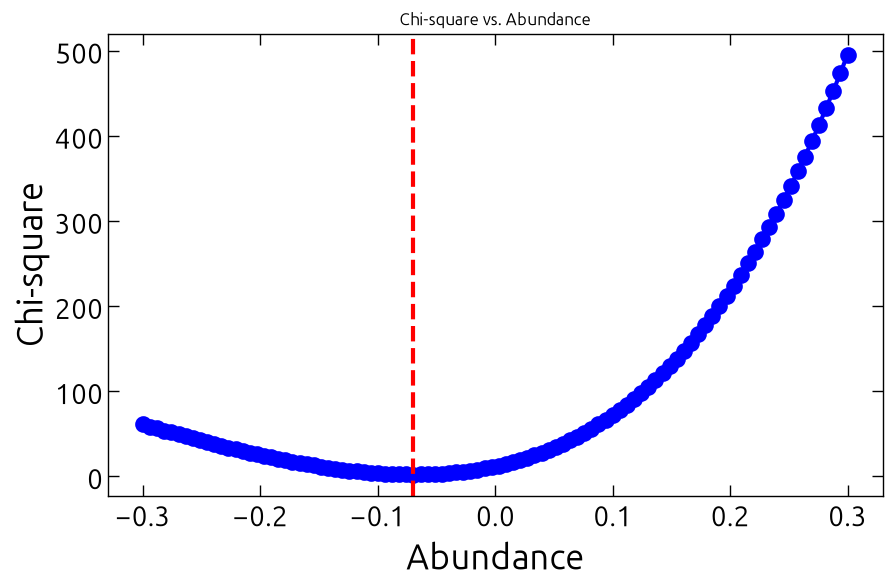

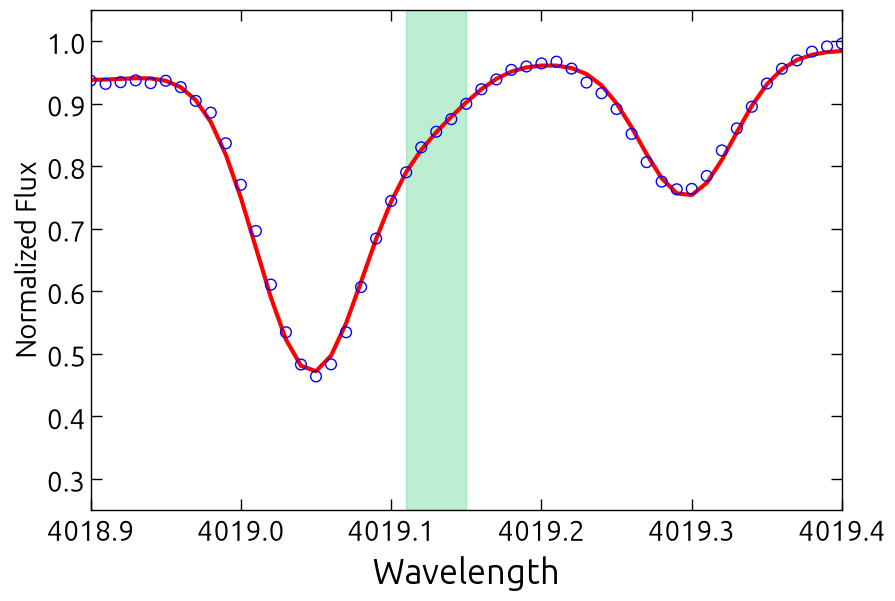

In [133]:
vtn   = vt + err_vt

Th_vtn = quel.Th_ximin(starid=starid, teff=teff, logg=logg, feh=feh, vt=vtn, ab_lm=ab_lm, 
                                  nsteps=nsteps, wl_start=wl_start, wl_end=wl_end, line=line, resol=resol, 
                                  vsini=vsini, macro_v=macro_v, SNR=SNR, y_shift_mult=y_shift_mult, 
                                  wl_shift=wl_shift)

In [134]:
Th_vt = abs(best_fit_abundance - Th_vtn)
Th_vt

pure_value = float(Th_vt)
print(pure_value)

0.0018151745532005853


### Total error

In [135]:
err_Th_up = np.sqrt(Th_up**2 + Th_teff**2 + Th_logg**2 + Th_feh**2 + Th_vt**2)
err_Th_lo = np.sqrt(Th_low**2 + Th_teff**2 + Th_logg**2 + Th_feh**2 + Th_vt**2)
print('A(Th) = %.3f^{%.3f}_{%.3f}' % (Th, err_Th_up, err_Th_lo))

A(Th) = -0.030^{0.028}_{0.040}
